In [13]:
import matplotlib.pyplot as plt
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
# define input size, hidden layer size, output size
D_i, D_k, D_o = 10, 40, 5
# create model with two hidden layers
model = nn.Sequential(
    nn.Linear(D_i, D_k),
    nn.ReLU(),
    nn.Linear(D_k, D_k),
    nn.ReLU(),
    nn.Linear(D_k, D_o))
# He initialization of weights
def weights_init(layer_in):
    if isinstance(layer_in, nn.Linear):
        nn.init.kaiming_normal_(layer_in.weight)
        layer_in.bias.data.fill_(0.0)
model.apply(weights_init)
# choose least squares loss function
criterion = nn.MSELoss()
# construct SGD optimizer and initialize learning rate and momentum
optimizer = torch.optim.SGD(model.parameters(), lr = 0.1, momentum=0.9)
# object that decreases learning rate by half every 10 epochs
scheduler = StepLR(optimizer, step_size=10, gamma=0.5)
# create 100 random data points and store in data loader class
x = torch.randn(100, D_i)
y = torch.randn(100, D_o)
data_loader = DataLoader(TensorDataset(x,y), batch_size=10, shuffle=True)
# create arrays for storing losses at each epoch
losses = np.zeros((100))
# loop over the dataset 100 times
for epoch in range(100):
    epoch_loss = 0.0
    # loop over batches
    for i, data in enumerate(data_loader):
    # retrieve inputs and labels for this batch
        x_batch, y_batch = data
        # zero the parameter gradients
        optimizer.zero_grad()
        # forward pass
        pred = model(x_batch)
        loss = criterion(pred, y_batch)
        # backward pass
        loss.backward()
        # SGD update
        optimizer.step()
        # update statistics
        epoch_loss += loss.item()
    # store loss at epoch
    losses[epoch] = epoch_loss
    # print error
    print(f'Epoch {epoch:5d}, loss {epoch_loss:.3f}')
    # tell scheduler to consider updating learning rate
    scheduler.step()


Epoch     0, loss 17.252
Epoch     1, loss 9.921
Epoch     2, loss 8.769
Epoch     3, loss 8.317
Epoch     4, loss 7.457
Epoch     5, loss 6.558
Epoch     6, loss 6.169
Epoch     7, loss 5.619
Epoch     8, loss 5.293
Epoch     9, loss 4.991
Epoch    10, loss 4.562
Epoch    11, loss 4.206
Epoch    12, loss 3.759
Epoch    13, loss 3.641
Epoch    14, loss 3.408
Epoch    15, loss 3.482
Epoch    16, loss 3.246
Epoch    17, loss 3.186
Epoch    18, loss 3.048
Epoch    19, loss 2.862
Epoch    20, loss 2.655
Epoch    21, loss 2.600
Epoch    22, loss 2.519
Epoch    23, loss 2.470
Epoch    24, loss 2.425
Epoch    25, loss 2.378
Epoch    26, loss 2.341
Epoch    27, loss 2.289
Epoch    28, loss 2.280
Epoch    29, loss 2.221
Epoch    30, loss 2.174
Epoch    31, loss 2.158
Epoch    32, loss 2.140
Epoch    33, loss 2.129
Epoch    34, loss 2.119
Epoch    35, loss 2.105
Epoch    36, loss 2.095
Epoch    37, loss 2.090
Epoch    38, loss 2.072
Epoch    39, loss 2.059
Epoch    40, loss 2.048
Epoch    41, lo

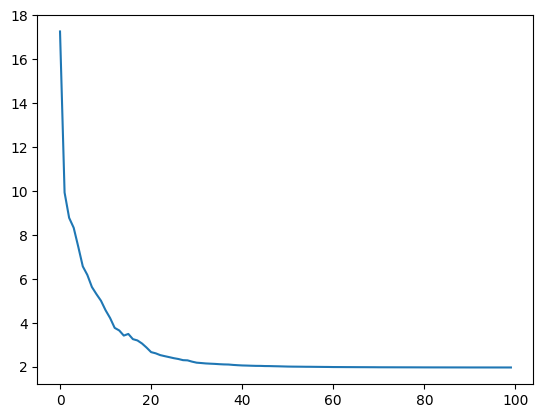

In [15]:
# plot losses against epochs
epochs = np.arange(100)
plt.plot(epochs, losses)


In [31]:
# for binary classification

# define input size, hidden layer size, output size
D_i, D_k, D_o = 10, 40, 1
# create model with two hidden layers
bin_class_model = nn.Sequential(
    nn.Linear(D_i, D_k),
    nn.ReLU(),
    nn.Linear(D_k, D_k),
    nn.ReLU(),
    nn.Linear(D_k, D_o),
    nn.Sigmoid())
# He initialization of weights
def weights_init(layer_in):
    if isinstance(layer_in, nn.Linear):
        nn.init.kaiming_normal_(layer_in.weight)
        layer_in.bias.data.fill_(0.0)
bin_class_model.apply(weights_init)
# choose least squares loss function
cross_entropy_criterion = nn.BCELoss()
# construct SGD optimizer and initialize learning rate and momentum
ce_optimizer = torch.optim.SGD(bin_class_model.parameters(), lr = 0.1, momentum=0.9)
# object that decreases learning rate by half every 10 epochs
ce_scheduler = StepLR(ce_optimizer, step_size=10, gamma=0.5)
# create 100 random data points and store in data loader class
x = torch.randn(100, D_i)
probabilities = torch.rand(100)
y = torch.bernoulli(probabilities)
ce_data_loader = DataLoader(TensorDataset(x,y), batch_size=10, shuffle=True)
# create arrays for storing losses at each epoch
cross_entropy_losses = np.zeros((100))
# loop over the dataset 100 times
for epoch in range(100):
    epoch_loss = 0.0
    # loop over batches
    for i, data in enumerate(ce_data_loader):
    # retrieve inputs and labels for this batch
        x_batch, y_batch = data
        y_batch = y_batch.unsqueeze(1)
        # zero the parameter gradients
        ce_optimizer.zero_grad()
        # forward pass
        pred = bin_class_model(x_batch)
        cross_entropy_loss = cross_entropy_criterion(pred, y_batch)
        # backward pass
        cross_entropy_loss.backward()
        # SGD update
        ce_optimizer.step()
        # update statistics
        epoch_loss += cross_entropy_loss.item()
    # store loss at epoch
    cross_entropy_losses[epoch] = epoch_loss
    # print error
    print(f'Epoch {epoch:5d}, loss {epoch_loss:.3f}')
    # tell scheduler to consider updating learning rate
    ce_scheduler.step()

Epoch     0, loss 10.062
Epoch     1, loss 6.282
Epoch     2, loss 4.590
Epoch     3, loss 3.257
Epoch     4, loss 3.133
Epoch     5, loss 4.291
Epoch     6, loss 4.790
Epoch     7, loss 3.683
Epoch     8, loss 3.895
Epoch     9, loss 1.840
Epoch    10, loss 1.218
Epoch    11, loss 0.612
Epoch    12, loss 0.504
Epoch    13, loss 0.357
Epoch    14, loss 0.353
Epoch    15, loss 0.268
Epoch    16, loss 0.245
Epoch    17, loss 0.222
Epoch    18, loss 0.197
Epoch    19, loss 0.188
Epoch    20, loss 0.173
Epoch    21, loss 0.168
Epoch    22, loss 0.163
Epoch    23, loss 0.158
Epoch    24, loss 0.154
Epoch    25, loss 0.149
Epoch    26, loss 0.146
Epoch    27, loss 0.141
Epoch    28, loss 0.138
Epoch    29, loss 0.134
Epoch    30, loss 0.131
Epoch    31, loss 0.129
Epoch    32, loss 0.128
Epoch    33, loss 0.126
Epoch    34, loss 0.125
Epoch    35, loss 0.124
Epoch    36, loss 0.122
Epoch    37, loss 0.120
Epoch    38, loss 0.119
Epoch    39, loss 0.117
Epoch    40, loss 0.117
Epoch    41, lo

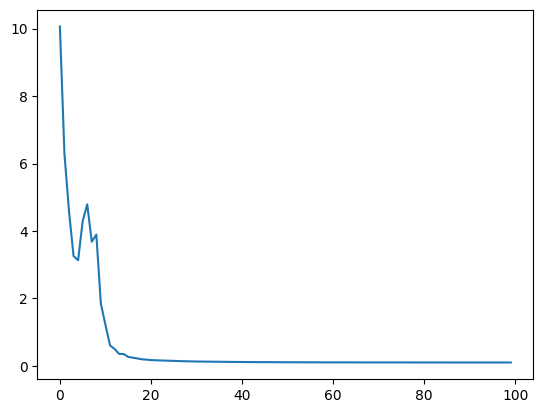

In [32]:
# plot losses against epochs
plt.plot(epochs, cross_entropy_losses)
